# Code: Time Series Features

*Prepared by Michael Lawrence Castanares*

Note: Most of the contents are taken from my MSDS Time Series class taught by Prof. Sebastian Ibanez, PhD

In [1]:
# Run only once
# %%capture
# !pip install tsfeatures
# !wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/aus_tourism.csv' -P ./data/

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tsfeatures import *
import time
from IPython.display import clear_output

In [3]:
pd.set_option("display.precision", 3)
np.set_printoptions(suppress=True)

def plot_series(df, time_col, target_col, ylabel, xlabel, title):
  df = df.set_index(time_col)
  df[target_col].plot()
  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.autoscale()
  plt.show()

## Australian Tourism Data

Here we take consider the Australian Tourism data with the following fields

* ds - time (Quarterly)
* Region - Region 
* State - State ['South Australia', 'Northern Territory', 'Western * Australia', 'Victoria', 'New South Wales', 'Queensland', 'ACT', 'Tasmania']
* Purpose - purpose of visit ['Business', 'Holiday', 'Other', 'Visiting']

In [4]:
df_tourism = pd.read_csv('data/aus_tourism.csv',
                         parse_dates = ['ds'])
df_tourism.tail()

,unique_id,ds,y
24315,Yorke Peninsula-South Australia-Visiting,2016-12-31,33.672
24316,Yorke Peninsula-South Australia-Visiting,2017-03-31,46.223
24317,Yorke Peninsula-South Australia-Visiting,2017-06-30,50.583
24318,Yorke Peninsula-South Australia-Visiting,2017-09-30,27.767
24319,Yorke Peninsula-South Australia-Visiting,2017-12-31,46.282


In [5]:
#separate unique_id to region, state, purpose
df_tourism[['Region', 'State', 'Purpose']] = df_tourism['unique_id'].str.split('-', expand=True)
df_tourism.head()

,unique_id,ds,y,Region,State,Purpose
0,Adelaide-South Australia-Business,1998-03-31,135.078,Adelaide,South Australia,Business
1,Adelaide-South Australia-Business,1998-06-30,109.987,Adelaide,South Australia,Business
2,Adelaide-South Australia-Business,1998-09-30,166.035,Adelaide,South Australia,Business
3,Adelaide-South Australia-Business,1998-12-31,127.160,Adelaide,South Australia,Business
4,Adelaide-South Australia-Business,1999-03-31,137.449,Adelaide,South Australia,Business


Showing first plot, closing others to save memory...


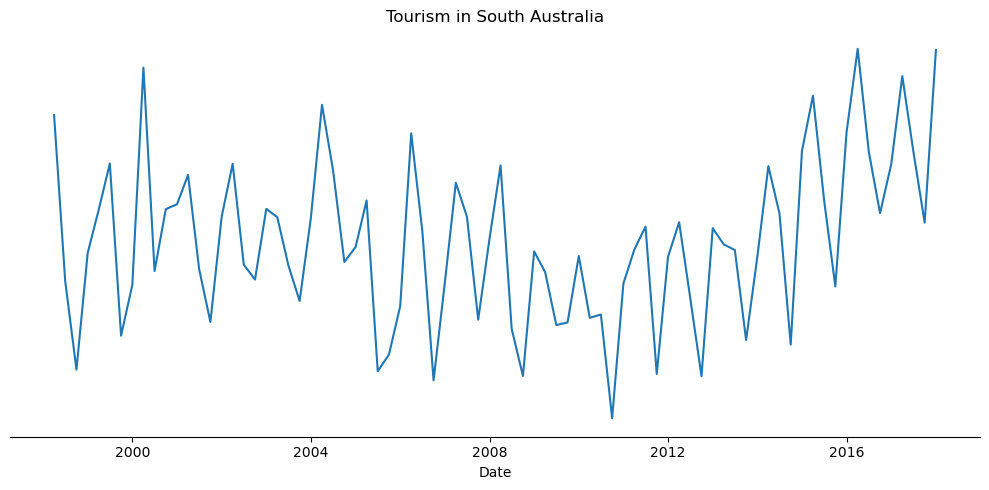

Successfully plotted 8 states, see ./figures
Time Elapsed: 0.98 seconds


In [13]:
#plot series in by state
start = time.time()
states = df_tourism['State'].unique()
n_states = len(states)
for i, state in enumerate(states):
    fig = plt.figure(figsize=(10, 5))
    state_data = df_tourism[df_tourism['State'] == state]
    state_data = (state_data
                  .groupby('ds')['y']
                  .sum()
                  .reset_index())
    plt.plot(state_data['ds'], state_data['y'])
    plt.title(f'Tourism in {state}')
    plt.ylabel('Number of Visitors')
    plt.xlabel('Date')

    for x in ['top', 'right', 'left']:
        plt.gca().spines[x].set_visible(False)
    #remove y-axis
    plt.gca().axes.get_yaxis().set_visible(False)
    plt.tight_layout()
    if i == 0:
        print('Showing first plot, closing others to save memory...')
        plt.show()
    fig.savefig(f'figures/tourism_{state}.png')
    plt.close(fig)

print(f'Successfully plotted {n_states} states, see ./figures')
print(f'Time Elapsed: {time.time() - start:0.2f} seconds')

In [7]:
#compute features for each region
df_region = (df_tourism[df_tourism['State'] == 'New South Wales']
 .groupby(['ds','Region'])['y']
 .sum()
 .reset_index()
)
df_region.columns = ['ds', 'unique_id', 'y']

start = time.time()
tourism_stl = tsfeatures(df_region,
           freq=4,
           features=[stl_features],
           scale=False)
display(tourism_stl.head())
print(f'Successfully computed features for {len(df_region["unique_id"].unique())} regions.')
print(f'Time Elapsed: {time.time() - start:.2f} seconds')


,unique_id,nperiods,seasonal_period,trend,spike,linearity,curvature,e_acf1,e_acf10,seasonal_strength,peak,trough
0,Blue Mountains,1,4,0.800,46.859,41.438,291.760,-0.501,0.543,0.607,2,1
1,Capital Country,1,4,0.670,57.224,151.083,168.589,-0.437,0.246,0.443,4,1
2,Central Coast,1,4,0.597,174.832,-133.074,101.016,-0.475,0.469,0.843,1,3
3,Central NSW,1,4,0.713,252.817,-10.828,311.158,-0.520,0.498,0.477,4,1
4,Hunter,1,4,0.704,860.070,354.846,317.121,-0.485,0.703,0.513,1,3


Successfully computed features for 13 regions.
Time Elapsed: 11.17 seconds


Showing first plot, closing others to save memory...


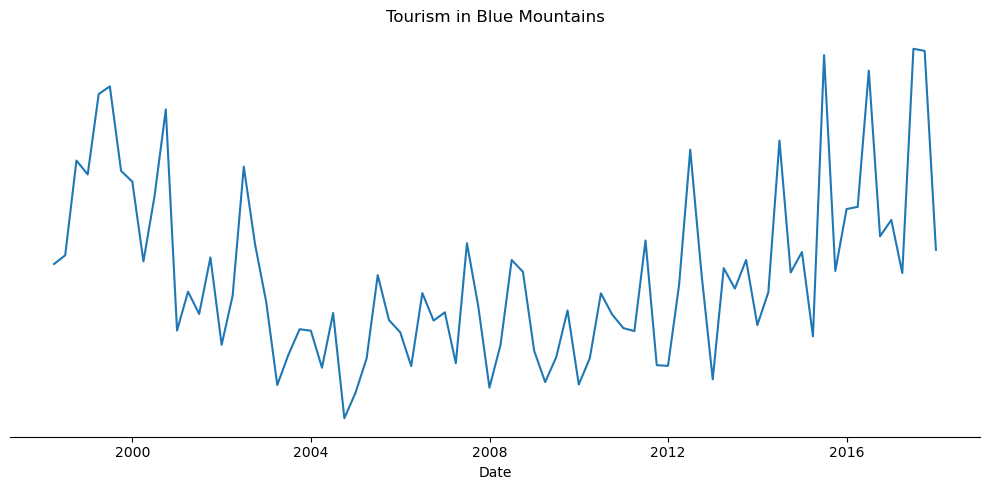

Successfully plotted 13 regions.
Time Elapsed: 1.56 seconds


In [8]:
df_temp = df_region.groupby(['ds', 'unique_id'])['y'].sum().unstack()
start = time.time()

for i, col in enumerate(df_temp.columns):
    fig = plt.figure(figsize=(10, 5))
    plt.plot(df_temp.index, df_temp[col], label=col)
    plt.title(f'Tourism in {col}')
    plt.ylabel('Number of Visitors')
    plt.xlabel('Date')

    for x in ['top', 'right', 'left']:
        plt.gca().spines[x].set_visible(False)
    #remove y-axis
    plt.gca().axes.get_yaxis().set_visible(False)
    plt.tight_layout()
    if i == 0:
        print('Showing first plot, closing others to save memory...')
        plt.show()
    fig.savefig(f'figures/tourism_region_{col}.png')
    plt.close(fig)

print(f'Successfully plotted {len(df_region["unique_id"].unique())} regions.')
print(f'Time Elapsed: {time.time() - start:.2f} seconds')


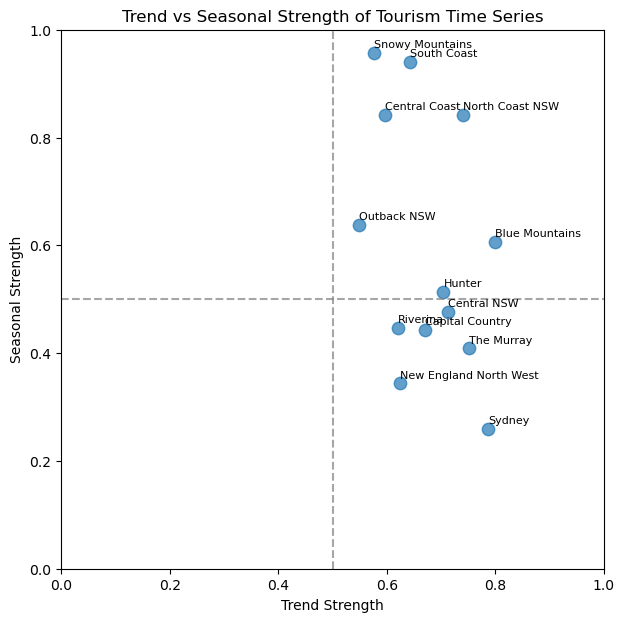

In [9]:
#Scatter plot of trend vs seasonal strength
fig, ax = plt.subplots(figsize=(7, 7))
tourism_stl.plot(kind='scatter',
                   x='trend',
                   y='seasonal_strength',
                   legend=True,
                   alpha=0.7,
                   s = 80,
                   ax=ax)
#set point size

#add labels to points
for i, row in tourism_stl.iterrows():
    ax.text(row['trend'],
            row['seasonal_strength'] + 0.01,
            row['unique_id'], fontsize=8)
ax.set_title('Trend vs Seasonal Strength of Tourism Time Series')
ax.set_xlabel('Trend Strength')
ax.set_ylabel('Seasonal Strength')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.vlines(x=0.5, ymin=0, ymax=1, color='grey', linestyle='--', alpha=0.7)
ax.hlines(y=0.5, xmin=0, xmax=1, color='grey', linestyle='--', alpha=0.7)
plt.show()

## Seasonal plot

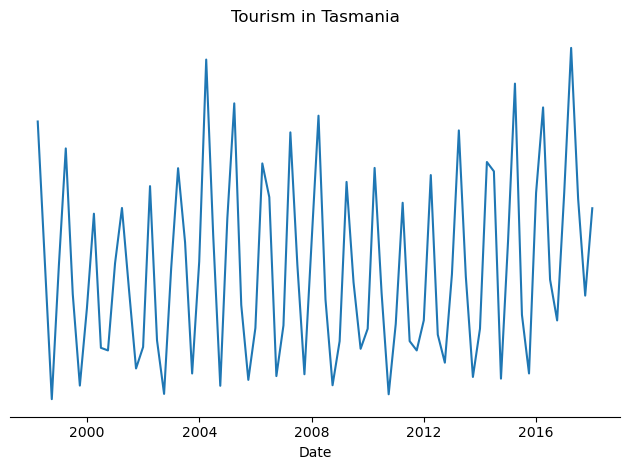

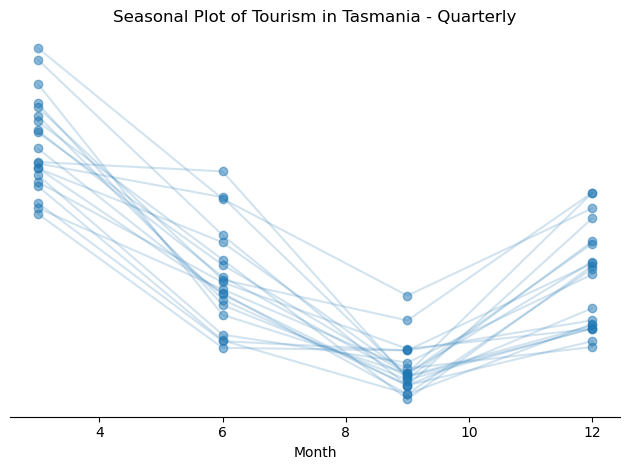

In [10]:
state = 'Tasmania'
state_data = df_tourism[df_tourism['State'] == state]
state_data = (state_data
                .groupby('ds')['y']
                .sum()
                .reset_index())
plt.plot(state_data['ds'], state_data['y'])
plt.title(f'Tourism in {state}')
plt.ylabel('Number of Visitors')
plt.xlabel('Date')

for x in ['top', 'right', 'left']:
    plt.gca().spines[x].set_visible(False)
#remove y-axis
plt.gca().axes.get_yaxis().set_visible(False)
plt.tight_layout()
plt.show()

#create seasonal plot
state_data['Month'] = state_data['ds'].dt.month
state_data['Year'] = state_data['ds'].dt.year

for year in state_data['Year'].unique():
    data_year = state_data[state_data['Year'] == year]
    plt.scatter(data_year['Month'],
             data_year['y'],
             color='tab:blue',
             alpha = 0.5,
             label=year)
    plt.plot(data_year['Month'],
             data_year['y'],
             color='tab:blue',
             alpha = 0.2)
plt.title(f'Seasonal Plot of Tourism in {state} - Quarterly')
plt.xlabel('Month')

#set x-lim
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for x in ['top', 'right', 'left']:
    plt.gca().spines[x].set_visible(False)
#remove y-axis
plt.gca().axes.get_yaxis().set_visible(False)
plt.tight_layout()
plt.show()





,ds,y,unique_id,MA_8Qtrs
0,1998-03-31,4041.370,Queensland,NaN
1,1998-06-30,3967.905,Queensland,NaN
2,1998-09-30,4593.894,Queensland,NaN
3,1998-12-31,4202.829,Queensland,NaN
4,1999-03-31,4332.491,Queensland,NaN


Showing first plot, closing others to save memory...


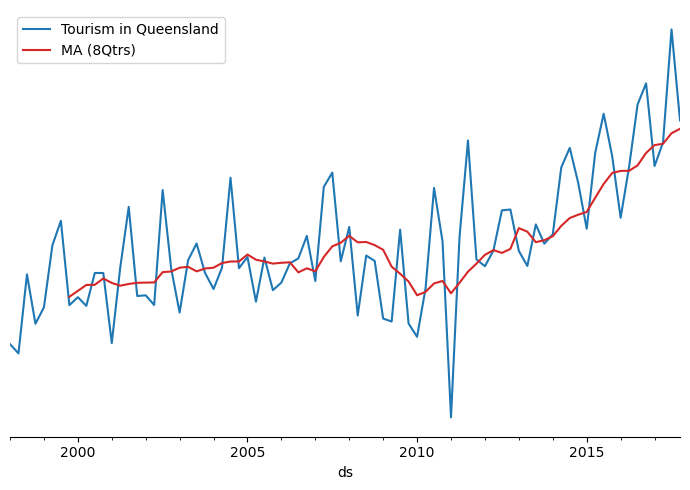

,0
unique_id,Queensland
entropy,0.713
x_acf1,0.543
x_acf10,1.379
diff1_acf1,-0.26
diff1_acf10,0.837
diff2_acf1,-0.394
diff2_acf10,0.629
seas_acf1,0.572
nperiods,1


Time Elapsed: 8.51 seconds


In [34]:
# Sample analysis for Queensland Tourism

state_data = (df_tourism[df_tourism['State'] == 'Queensland']
 .groupby('ds')['y']
 .sum()
 .reset_index()
)
state_data['unique_id'] = 'Queensland'

#calculate MA 8 quarters
state_data['MA_8Qtrs'] = state_data['y'].rolling(window=8).mean()
display(state_data.head())   


fig, ax = plt.subplots(1,1, figsize=(7, 5))
state_data.plot(x = 'ds', y = 'y', 
                ax=ax,
                label='Tourism in Queensland',)
state_data.plot(x = 'ds', y = 'MA_8Qtrs', 
                ax=ax, 
                label='MA (8Qtrs)', 
                color='tab:red')
i=0
for x in ['top', 'right', 'left']:
    plt.gca().spines[x].set_visible(False)
#remove y-axis
plt.gca().axes.get_yaxis().set_visible(False)
plt.tight_layout()
if i == 0:
    print('Showing first plot, closing others to save memory...')
    plt.show()
plt.close(fig)

start = time.time()
tourism_stl = tsfeatures(state_data,
           freq=4,
           features=[stl_features,
                     acf_features,
                     entropy],
           scale=False)

display(tourism_stl.T)
print(f'Time Elapsed: {time.time() - start:.2f} seconds')

# Australian Property Prices

In [42]:
# Property Price
df_prop = pd.read_excel('data/643201.xlsx',
                        sheet_name='Data1',)
labels = df_prop.columns.tolist()
labels[0] = 'ds'
df_prop = df_prop.iloc[9:,:]
df_prop.reset_index(drop=True, inplace=True)
df_prop.columns = labels
df_prop.head()

,ds,Value of dwelling stock; Owned by Households ; New South Wales ;,Value of dwelling stock; Owned by Households ; Victoria ;,Value of dwelling stock; Owned by Households ; Queensland ;,Value of dwelling stock; Owned by Households ; South Australia ;,Value of dwelling stock; Owned by Households ; Western Australia ;,Value of dwelling stock; Owned by Households ; Tasmania ;,Value of dwelling stock; Owned by Households ; Northern Territory ;,Value of dwelling stock; Owned by Households ; Australian Capital Territory ;,Value of dwelling stock; Owned by Households ; Australia ;,...,Mean price of residential dwellings ; Australia ;,Number of residential dwellings ; New South Wales ;,Number of residential dwellings ; Victoria ;,Number of residential dwellings ; Queensland ;,Number of residential dwellings ; South Australia ;,Number of residential dwellings ; Western Australia ;,Number of residential dwellings ; Tasmania ;,Number of residential dwellings ; Northern Territory ;,Number of residential dwellings ; Australian Capital Territory ;,Number of residential dwellings ; Australia ;
0,2011-09-01 00:00:00,1453495,1121374.8,723858.5,253939.4,464342.1,65479.7,30196.1,72384.2,4185069.8,...,490.8,2839,2265.6,1784.5,722.3,942,230.5,74,144.9,9002.7
1,2011-12-01 00:00:00,1442134.3,1114587.1,721480.1,257468.3,463152.5,66647.4,27445,74701.4,4167616.1,...,486.9,2845.1,2278.3,1791.7,724.6,946.3,231.1,74.4,145.8,9037.2
2,2012-03-01 00:00:00,1476077.7,1104613.8,717810.5,253614,474579.7,65710.3,26899,73903,4193208,...,488.6,2850.3,2287.7,1796.2,726.3,950.2,231.6,74.7,146.4,9063.4
3,2012-06-01 00:00:00,1492911,1110654.2,722320.4,254790.2,475476.2,63755.8,26825.8,74278.5,4221012,...,489.9,2856.3,2299.2,1803.9,728.5,954.9,232.1,75.1,147.5,9097.6
4,2012-09-01 00:00:00,1476006.3,1097055.5,730611.1,254105.2,484668,63024.1,27295.7,73549.6,4206315.6,...,486.3,2862.8,2309.8,1811.2,730.4,959.5,232.6,75.5,148.3,9130.2


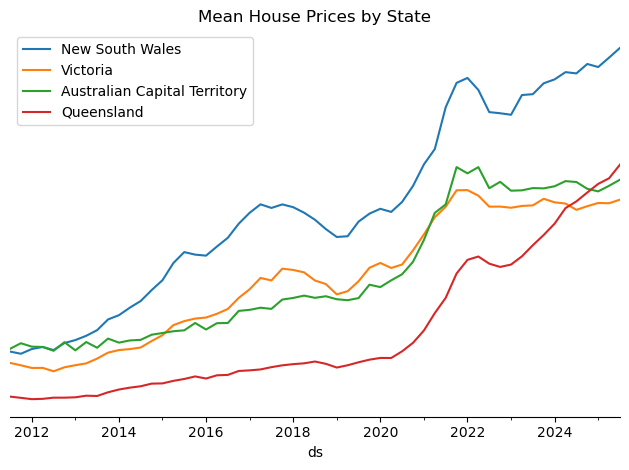

In [43]:
#select only columns that contain mean
df_prices = df_prop.loc[:, df_prop.columns.str.contains('Mean')]
state = [x.split(';')[-2].strip() for x in df_prices.columns.tolist()]
df_prices.columns = state
df_prices.insert(0, 'ds', pd.to_datetime(df_prop['ds']))
df_prices.set_index('ds', inplace=True)


#SELECT SPECIFIC STATES
SELECT_STATES = ['New South Wales',
                 'Victoria',
                 'Australian Capital Territory',
                 'Queensland',]

df_prices[SELECT_STATES].plot()

for x in ['top', 'right', 'left']:
    plt.gca().spines[x].set_visible(False)
#remove y-axis
plt.title('Mean House Prices by State')
plt.gca().axes.get_yaxis().set_visible(False)
plt.tight_layout()
plt.show()


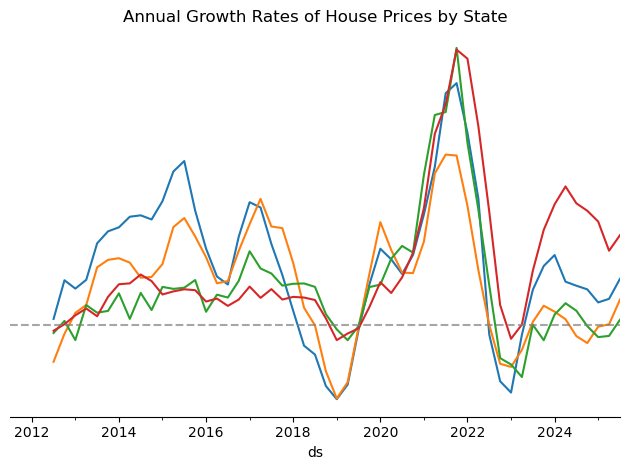

In [62]:
#take yoy growth rate
df_prices_gr = df_prices.pct_change(4)
#SELECT SPECIFIC STATES
SELECT_STATES = ['New South Wales',
                 'Victoria',
                 'Australian Capital Territory',
                 'Queensland',]

df_prices_gr[SELECT_STATES].plot(legend=False)

for x in ['top', 'right', 'left']:
    plt.gca().spines[x].set_visible(False)
#remove y-axis
plt.title('Annual Growth Rates of House Prices by State')
plt.gca().axes.get_yaxis().set_visible(False)
plt.axhline(0, color='grey', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [60]:
#apply ADF and KPSS test


def stationarity_tests(series, name):

    from statsmodels.tsa.stattools import adfuller, kpss

    result = adfuller(series.dropna())
    stat, p_val = result[0], result[1]

    result_kpss = kpss(series.dropna(), regression='c')
    stat_kpss, p_val_kpss = result_kpss[0], result_kpss[1]

    output = {'name': name,
              'adf_stat': stat,
              'adf_p_val': p_val,
              'adf_H0': 'Series has a unit root (non-stationary)',
              'stat_kpss': stat_kpss,
              'kpss_p_val': p_val_kpss,
              'kpss_H0': 'Series is stationary'}

    return output


collect = []
for state in SELECT_STATES:
    collect.append(stationarity_tests(df_prices_gr[state], state))

pd.DataFrame.from_records(collect)

,name,adf_stat,adf_p_val,adf_H0,stat_kpss,kpss_p_val,kpss_H0
0,New South Wales,-2.631,0.087,Series has a unit root (non-stationary),0.100,0.100,Series is stationary
1,Victoria,-3.091,0.027,Series has a unit root (non-stationary),0.135,0.100,Series is stationary
2,Australian Capital Territory,-1.967,0.301,Series has a unit root (non-stationary),0.123,0.100,Series is stationary
3,Queensland,-1.988,0.292,Series has a unit root (non-stationary),0.460,0.051,Series is stationary
